This project builds a machine learning model to predict Bitcoin (BTC) closing prices.
We use historical BTC market data for training.
The goal is to learn patterns from past price movements.
Finally, we deploy the trained model for real-time prediction.

We import libraries required for data analysis and modeling.
Pandas and NumPy handle data processing.
Matplotlib is used for visualization.
Scikit-learn helps train and evaluate the model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle

We load the Bitcoin (BTC) historical dataset.
The dataset contains Open, High, Low, Volume, and Close prices.
This data represents past market performance.
It will be used to train the prediction model.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving BTC.csv to BTC.csv


Reads the BTC.csv file using pandas.

Stores the data inside a dataframe called df.

df.head() shows the first 5 rows.

Helps check if the data loaded correctly.

In [4]:
df = pd.read_csv("BTC.csv")
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


df.info() shows number of rows, columns, and data types.

Confirms there are no missing values.

df.describe() shows statistical summary.

Displays mean, min, max, and other values.

In [5]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3645 entries, 0 to 3644
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3645 non-null   object 
 1   Open       3645 non-null   float64
 2   High       3645 non-null   float64
 3   Low        3645 non-null   float64
 4   Close      3645 non-null   float64
 5   Adj Close  3645 non-null   float64
 6   Volume     3645 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 199.5+ KB


,Open,High,Low,Close,Adj Close,Volume
count,3645.000000,3645.000000,3645.000000,3645.000000,3645.000000,3.645000e+03
mean,17705.901266,18108.188591,17274.844491,17719.664944,17719.664944,1.758548e+10
std,19538.042884,19974.936027,19055.764532,19543.729167,19543.729167,1.918558e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,1145.520020,1180.160034,1116.959961,1150.000000,1150.000000,2.880610e+08
50%,9131.812500,9287.471680,8908.447266,9137.993164,9137.993164,1.377740e+10
75%,29084.666016,29452.455078,28701.779297,29098.910156,29098.910156,2.847970e+10
max,73079.375000,73750.070312,71334.093750,73083.500000,73083.500000,3.509679e+11


Data cleaning & feature selection

Removes any missing values using dropna().

Selects Open, High, Low, Volume as input features (X).

Selects Close price as target (y).

Prepares data for model training.

In [6]:
df = df.dropna()

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

Splits data into training and testing sets.

80% data for training, 20% for testing.

random_state=42 keeps results consistent.

Prevents overfitting by testing on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Creates a Linear Regression model.

Trains the model using training data.

Learns relationship between inputs and close price.

Builds prediction formula internally.

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Uses trained model to predict test data.

Stores predicted values in y_pred.

Compares predictions with actual values.

Prepares for evaluation.



In [9]:
y_pred = model.predict(X_test)

Model evaluation

Calculates Mean Squared Error (MSE).

Lower MSE means better performance.

Calculates R² score.

R² close to 1 means very accurate model.

In [10]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 109896.44384638943
R2 Score: 0.999718030728159


Creates a scatter plot.

X-axis shows actual prices.

Y-axis shows predicted prices.

If points align closely, model works well.

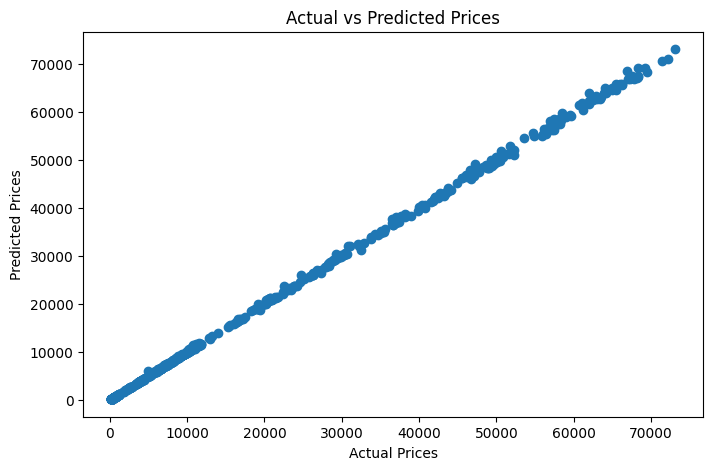

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [12]:
pickle.dump(model, open("model.pkl", "wb"))

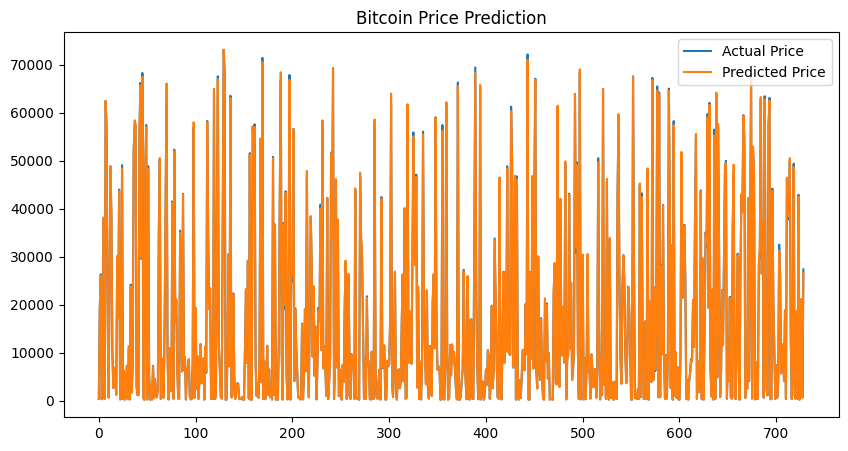

In [13]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Bitcoin Price Prediction")
plt.show()


In [14]:
print(X.shape)

(3645, 4)


In [15]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [16]:
!ls

BTC.csv  model.pkl  sample_data


In [17]:
app_code = """
import numpy as np
import pickle
from flask import Flask, request, render_template

app = Flask(__name__)

model = pickle.load(open("model.pkl", "rb"))

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    open_price = float(request.form["open"])
    high_price = float(request.form["high"])
    low_price = float(request.form["low"])
    volume = float(request.form["volume"])

    features = np.array([[open_price, high_price, low_price, volume]])
    prediction = model.predict(features)

    return render_template("index.html", prediction_text=f"Predicted Close Price: {prediction[0]:.2f}")

if __name__ == "__main__":
    app.run()
"""

with open("app.py", "w") as f:
    f.write(app_code)

In [18]:
!ls

app.py	BTC.csv  model.pkl  sample_data


In [19]:
!mkdir templates

In [20]:
html_code = """
<!DOCTYPE html>
<html>
<head>
    <title>Bitcoin Price Predictor</title>
    <link rel="stylesheet" href="/static/style.css">
</head>
<body>
<div class="container">
    <h1>Bitcoin Price Prediction</h1>

    <form action="/predict" method="post">
        <input type="number" step="any" name="open" placeholder="Open Price" required>
        <input type="number" step="any" name="high" placeholder="High Price" required>
        <input type="number" step="any" name="low" placeholder="Low Price" required>
        <input type="number" step="any" name="volume" placeholder="Volume" required>
        <button type="submit">Predict</button>
    </form>

    <h2>{{ prediction_text }}</h2>
</div>
</body>
</html>
"""

with open("templates/index.html", "w") as f:
    f.write(html_code)

In [21]:
!mkdir static

In [22]:
css_code = """
body {
    background-color: #111;
    color: white;
    font-family: Arial;
    text-align: center;
}

.container {
    margin-top: 100px;
}

input {
    padding: 10px;
    margin: 10px;
    width: 250px;
    border-radius: 5px;
    border: none;
}

button {
    padding: 10px 20px;
    background-color: orange;
    border: none;
    border-radius: 5px;
    cursor: pointer;
}
"""

with open("static/style.css", "w") as f:
    f.write(css_code)

In [23]:
req = """
flask
numpy
scikit-learn
gunicorn
"""

with open("requirements.txt", "w") as f:
    f.write(req)

In [28]:
!ls templates
!ls static

index.html
style.css


In [29]:
!ls

app.py	BTC.csv  model.pkl  requirements.txt  sample_data  static  templates
